In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv(r"C:\Users\salma\Desktop\dalya\project healthcare\MA supply chain\first milestone\timeseries_version.csv", parse_dates=["Order_Date"])

# Sort by date
df = df.sort_values(by="Order_Date")

# Display first few rows
print(df.head())
print(df.info())  # Check missing values and data types


  Order_Date  Device_Type  Monthly_Demand  Lead_Time  Stock_Level  \
0 2018-01-01     Surgical             565         18          608   
1 2018-01-03  Therapeutic             480         12          497   
2 2018-01-05     Surgical             599          9          646   
3 2018-01-05   Monitoring             478         18          500   
4 2018-01-06   Monitoring             516         12          537   

   Supplier_Reliability  Seasonality_Factor  
0                  0.81            1.007333  
1                  0.91            0.975088  
2                  0.83            1.028933  
3                  0.82            1.044259  
4                  0.72            1.022368  
<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Order_Date            10000 non-null  datetime64[ns]
 1   Device_Type           10000 

In [9]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test to check stationarity
result = adfuller(df['Monthly_Demand'])
print(f"ADF Statistic: {result[0]}")
print(f"P-Value: {result[1]}")
if result[1] < 0.05:
    print("Series is stationary, no differencing needed.")
    d, D = 0, 0
else:
    print("Series is non-stationary, applying differencing.")
    df['Differenced'] = df['Monthly_Demand'].diff(12).diff()
    df.dropna(inplace=True)
    d, D = 1, 1


ADF Statistic: -0.44829799320945873
P-Value: 0.901717086266297
Series is non-stationary, applying differencing.


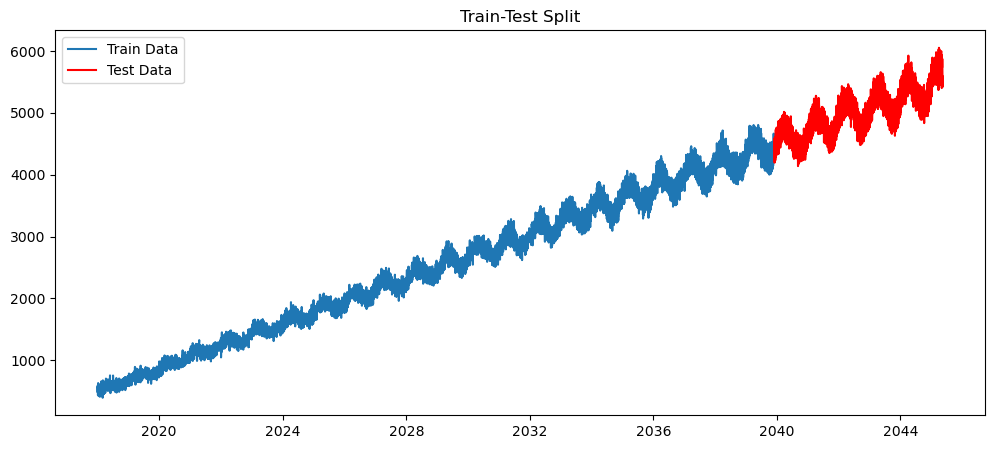

In [2]:
# Train-Test Split

# Set index as date
df.set_index("Order_Date", inplace=True)

# Define split point
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

# Plot train-test split
plt.figure(figsize=(12, 5))
plt.plot(train.index, train["Monthly_Demand"], label="Train Data")
plt.plot(test.index, test["Monthly_Demand"], label="Test Data", color="red")
plt.legend()
plt.title("Train-Test Split")
plt.show()

<h1> Forecasting with SARIMA

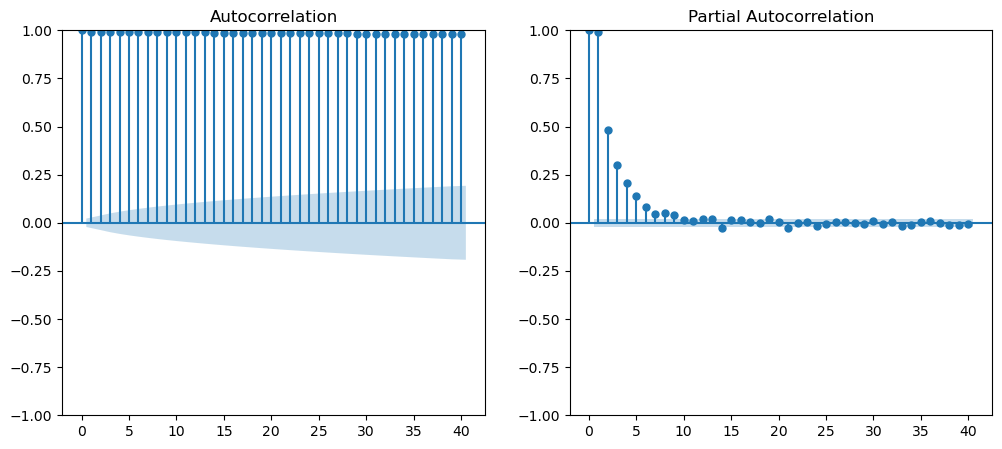

In [10]:
# Parameter (AR (p) and MA (q) orders) Selection Using ACF/PACF

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF and PACF plots
fig, ax = plt.subplots(1,2, figsize=(12,5))
plot_acf(train["Monthly_Demand"], ax=ax[0])
plot_pacf(train["Monthly_Demand"], ax=ax[1])
plt.show()

In [30]:
# Set SARIMA parameters based on ACF/PACF analysis
p, q = 3, 0  # Choose based on PACF (p) and ACF (q) plots
P, Q = 1, 1  # Seasonal orders determined by seasonal ACF/PACF
S = 12  # Seasonality period for monthly data

c:\Users\salma\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\salma\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\salma\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\salma\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_predict

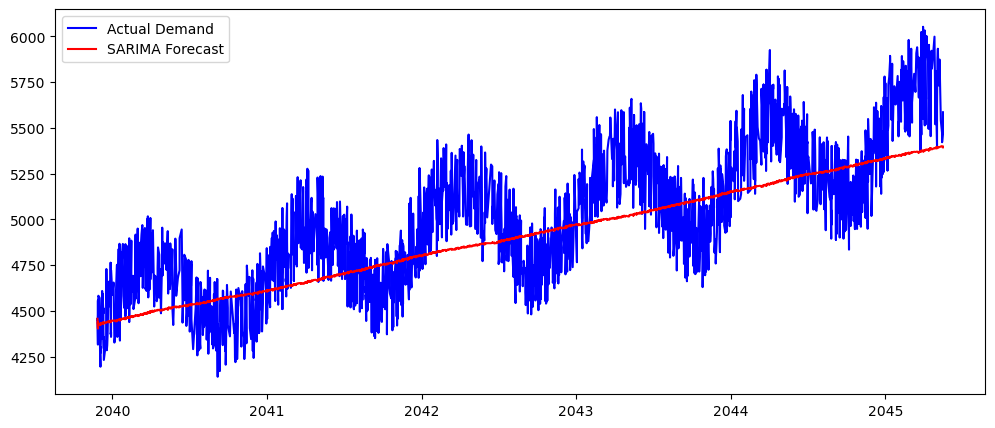

In [31]:
# Train the SARIMA Model

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Define SARIMA Model
sarima_model = SARIMAX(train["Monthly_Demand"], order=(p, d, q), seasonal_order=(P, D, Q, S))
sarima_fit = sarima_model.fit()

# Forecast
sarima_forecast = sarima_fit.forecast(steps=len(test))

# Plot forecast vs actual
plt.figure(figsize=(12,5))
plt.plot(test.index, test["Monthly_Demand"], label="Actual Demand", color="blue")
plt.plot(test.index, sarima_forecast, label="SARIMA Forecast", color="red")
plt.legend()
plt.show()

In [32]:
# Evaluate SARIMA Model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(test["Monthly_Demand"], sarima_forecast)
mse = mean_squared_error(test["Monthly_Demand"], sarima_forecast)
rmse = mse ** 0.5
r2 = r2_score(test["Monthly_Demand"], sarima_forecast)


print(f"SARIMA MAE: {mae:.2f}, RMSE: {rmse:.2f}, R-squared: {r2}")

SARIMA MAE: 210.72, RMSE: 257.83, R-squared: 0.5256006731581362
